In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload dataset
from google.colab import files
uploaded = files.upload()

Saving world_happiness_report_2005_2025.csv to world_happiness_report_2005_2025 (1).csv


In [2]:
import pandas as pd

df = pd.read_csv('world_happiness_report_2005_2025.csv')

df.head()

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = pd.read_csv('world_happiness_report_2005_2025.csv')

In [4]:
df.columns

Index(['year', 'rank_in_year', 'country', 'happiness_score', 'lower_whisker',
       'upper_whisker', 'explained_log_gdp_per_capita',
       'explained_social_support', 'explained_healthy_life_expectancy',
       'explained_freedom', 'explained_generosity', 'explained_corruption',
       'dystopia_plus_residual'],
      dtype='object')

In [5]:
# Dataset shape
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape:
(2116, 13)

Missing Values:
year                                    0
rank_in_year                            0
country                                 0
happiness_score                         0
lower_whisker                        1094
upper_whisker                        1094
explained_log_gdp_per_capita         1097
explained_social_support             1097
explained_healthy_life_expectancy    1100
explained_freedom                    1099
explained_generosity                 1097
explained_corruption                 1098
dystopia_plus_residual               1103
dtype: int64

Summary Statistics:


,year,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
count,2116.000000,2116.000000,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
mean,2018.220227,76.190926,5.465655,5.436091,5.664733,1.265670,1.096746,0.553435,0.609465,0.147343,0.144911,1.736935
std,4.249844,43.845101,1.123870,1.140959,1.107424,0.463823,0.357642,0.229980,0.212070,0.084335,0.118803,0.657497
min,2011.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,4.604750,4.619707,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063156,1.305000
50%,2018.000000,76.000000,5.480000,5.592631,5.812000,1.304000,1.140119,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,6.321250,6.290110,6.486500,1.636000,1.382000,0.712325,0.735000,0.195477,0.181330,2.178000
max,2025.000000,158.000000,7.856000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.569814,0.587000,3.482000


#**Distribution of Happiness Scores**


The histogram shows the distribution of happiness scores across countries and years. Most observations fall within the mid-range of happiness values, while relatively few countries have extremely high or extremely low scores.
<br><br>

The distribution appears moderately bell-shaped, suggesting that happiness scores are reasonably balanced across the dataset. However, some skewness is present, indicating that certain countries consistently experience significantly higher or lower happiness levels than others.
<br><br>

Understanding the distribution of the target variable is important because it helps determine whether predictive models may face imbalance issues or require transformations during preprocessing.

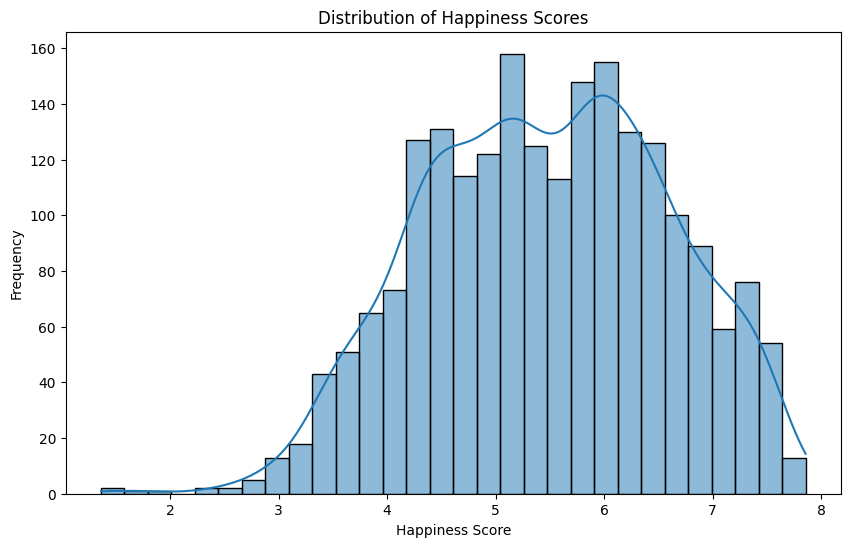

In [6]:
# Distribution of happiness scores

plt.figure(figsize=(10,6))
sns.histplot(df['happiness_score'], bins=30, kde=True)

plt.title('Distribution of Happiness Scores')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')

plt.show()

#**Correlation Analysis**

The correlation heatmap reveals several strong relationships between happiness scores and the explanatory variables. GDP per capita, social support, and healthy life expectancy appear to have the strongest positive correlations with happiness.

<br><br>

This suggests that countries with stronger economies, better healthcare systems, and stronger social support networks tend to report higher levels of happiness. Freedom also shows a positive relationship with happiness, though slightly weaker than the other variables.
<br><br>


Generosity and perceptions of corruption show weaker correlations, indicating that their influence on happiness may be less direct or more difficult to capture quantitatively.
<br><br>


The heatmap also helps identify multicollinearity between predictors, which is important when selecting and interpreting machine learning models.

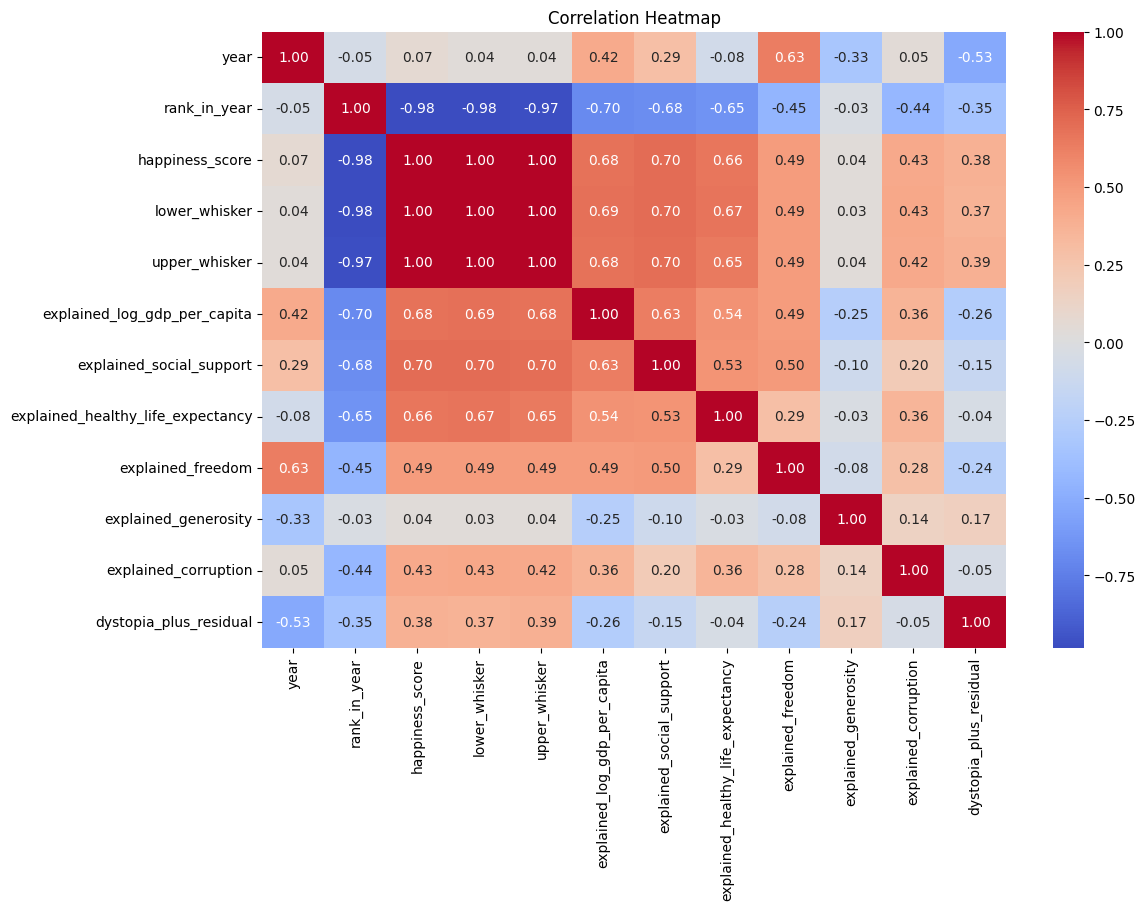

In [10]:
# Correlation heatmap

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

#**Happiness Trends Over Time**

The time series visualization shows how average global happiness scores have changed across the years included in the dataset. While fluctuations exist, the overall trend appears relatively stable with moderate variation between years.
<br><br>

Changes in global happiness levels may be influenced by economic conditions, political instability, public health crises, or social changes occurring during specific time periods. Observing temporal trends helps provide context for predictive modeling and supports broader interpretations of the data.

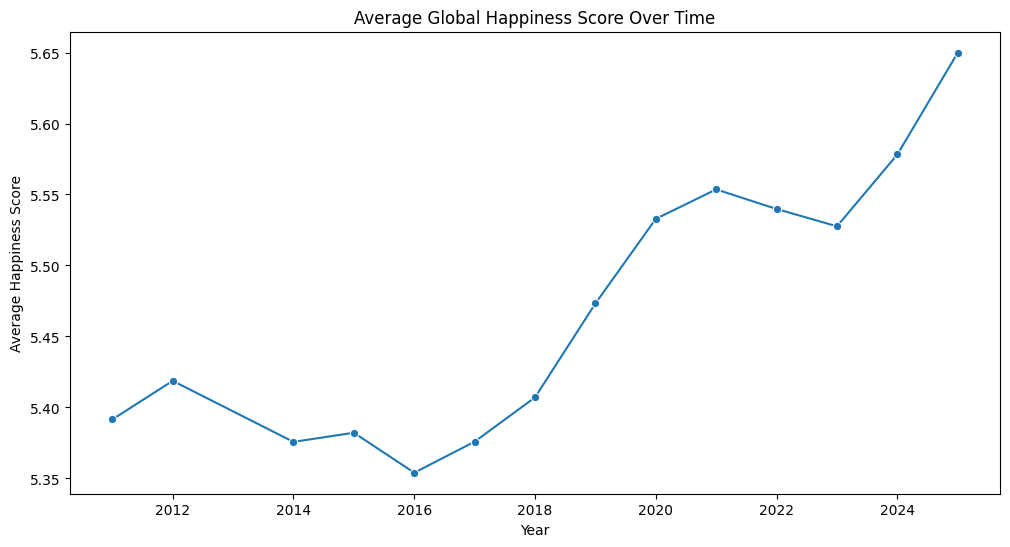

In [11]:
# Average happiness score by year

yearly_happiness = df.groupby('year')['happiness_score'].mean()

plt.figure(figsize=(12,6))

sns.lineplot(x=yearly_happiness.index,
             y=yearly_happiness.values,
             marker='o')

plt.title('Average Global Happiness Score Over Time')
plt.xlabel('Year')
plt.ylabel('Average Happiness Score')

plt.show()

#**Top Performing Countries**

The bar chart highlights the countries with the highest average happiness scores across the dataset. Countries appearing near the top consistently demonstrate strong economic conditions, social support systems, healthcare access, and institutional trust.
<br><br>


These findings support the broader conclusion that national well-being is strongly connected to both economic stability and social infrastructure. The visualization also demonstrates how happiness varies significantly across regions and countries.
These findings support the broader conclusion that national well-being is strongly connected to both economic stability and social infrastructure. The visualization also demonstrates how happiness varies significantly across regions and countries.

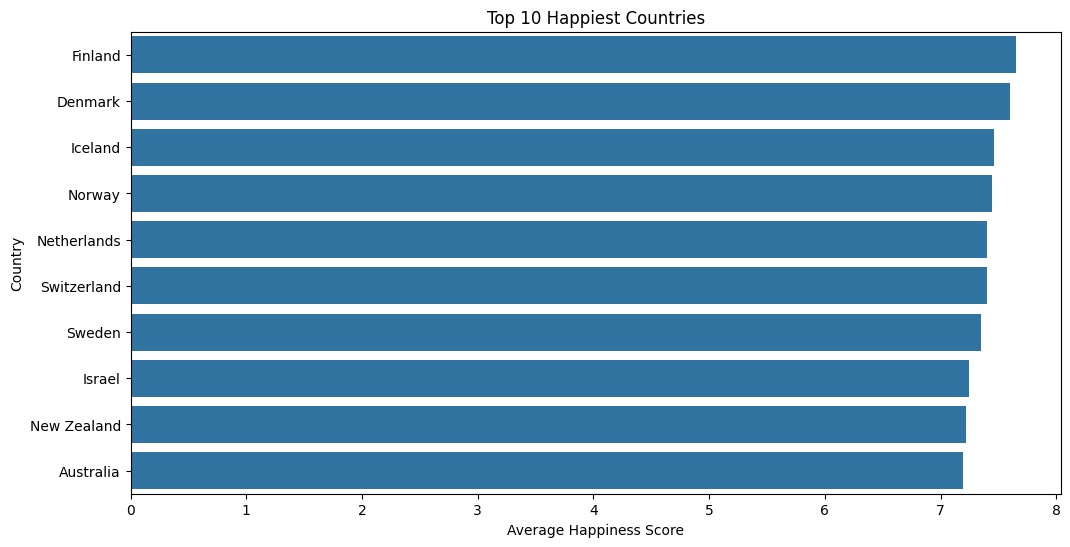

In [12]:
# Top 10 happiest countries

top_countries = (
    df.groupby('country')['happiness_score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(x=top_countries.values,
            y=top_countries.index)

plt.title('Top 10 Happiest Countries')
plt.xlabel('Average Happiness Score')
plt.ylabel('Country')

plt.show()

#**Handling Missing Values**

The dataset contained missing values in several explanatory variables. To ensure modeling accuracy and consistency, rows containing missing values were removed from the dataset during preprocessing.
<br><br>

Although removing observations reduces the dataset size slightly, this approach simplifies the modeling process and avoids introducing potential bias from imputation techniques. After cleaning, the dataset retained sufficient observations for meaningful analysis and predictive modeling.

In [13]:
# Check missing values

missing_values = df.isnull().sum()

print(missing_values)

year                                    0
rank_in_year                            0
country                                 0
happiness_score                         0
lower_whisker                        1094
upper_whisker                        1094
explained_log_gdp_per_capita         1097
explained_social_support             1097
explained_healthy_life_expectancy    1100
explained_freedom                    1099
explained_generosity                 1097
explained_corruption                 1098
dystopia_plus_residual               1103
dtype: int64


In [14]:
# Remove rows with missing values

df_clean = df.dropna()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (2116, 13)
Cleaned dataset shape: (1013, 13)


In [15]:
# Define features and target variable

X = df_clean.drop(columns=[
    'happiness_score',
    'country'
])

y = df_clean['happiness_score']

print("Feature columns:")
print(X.columns)

print("\nTarget variable:")
print(y.name)

Feature columns:
Index(['year', 'rank_in_year', 'lower_whisker', 'upper_whisker',
       'explained_log_gdp_per_capita', 'explained_social_support',
       'explained_healthy_life_expectancy', 'explained_freedom',
       'explained_generosity', 'explained_corruption',
       'dystopia_plus_residual'],
      dtype='object')

Target variable:
happiness_score


#**Feature Selection**

The target variable selected for prediction is the happiness score. Predictor variables include economic, social, health, and governance-related indicators such as GDP per capita, social support, healthy life expectancy, freedom, generosity, and corruption perceptions.
<br><br>

The country column was excluded from modeling because it serves primarily as an identifier rather than a predictive numerical feature.

#**Train-Test Split and Scaling**

The dataset was divided into training and testing sets using an 80/20 split. The training set was used to train machine learning models, while the testing set was reserved for evaluating predictive performance on unseen data.
<br><br>

Feature scaling was applied using StandardScaler to standardize the numerical variables. Scaling helps ensure that variables measured on different scales contribute more equally to machine learning algorithms, particularly regression-based models.

In [64]:

# ============================================
# TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (810, 7)
Testing set shape: (203, 7)


In [48]:
X = df_clean.drop(columns=[
    'happiness_score',
    'country',
    'lower_whisker',
    'upper_whisker',
    'dystopia_plus_residual',
    'rank_in_year'
])

y = df_clean['happiness_score']

print("Number of features:", X.shape[1])
print(X.columns)

Number of features: 7
Index(['year', 'explained_log_gdp_per_capita', 'explained_social_support',
       'explained_healthy_life_expectancy', 'explained_freedom',
       'explained_generosity', 'explained_corruption'],
      dtype='object')


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


#**Business Question 1**

Which socioeconomic factors have the strongest impact on national happiness levels?
<br><br>

This question aims to identify which variables most strongly influence happiness scores across countries. Understanding the relative importance of GDP, social support, life expectancy, freedom, generosity, and corruption can help policymakers prioritize investments and social programs that improve quality of life.

#**Business Question 2**

Can machine learning models accurately predict happiness scores using economic and social indicators?
<br><br>

This question evaluates whether predictive analytics models can successfully estimate national happiness levels based on measurable country-level variables. Accurate prediction models may help governments and organizations forecast well-being outcomes and monitor societal trends over time.

#**Business Question 3**

How do happiness levels vary across countries and over time?
<br><br>

This question explores global trends and differences in happiness scores between countries and across years. Understanding these trends may help identify long-term patterns related to economic growth, healthcare, governance, and social development.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('world_happiness_report_2005_2025.csv')

df.head()

In [50]:
df_clean = df.dropna()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (2116, 13)
Cleaned dataset shape: (1013, 13)


In [62]:
# ============================================
# FINAL FEATURE SELECTION
# ============================================

X = df_clean.drop(columns=[
    'happiness_score',
    'country',
    'lower_whisker',
    'upper_whisker',
    'dystopia_plus_residual',
    'rank_in_year'
])

y = df_clean['happiness_score']

print("Number of features:", X.shape[1])
print(X.columns)

Number of features: 7
Index(['year', 'explained_log_gdp_per_capita', 'explained_social_support',
       'explained_healthy_life_expectancy', 'explained_freedom',
       'explained_generosity', 'explained_corruption'],
      dtype='object')


In [68]:
# ============================================
# IMPORT MACHINE LEARNING LIBRARIES
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [65]:
# ============================================
# FEATURE SCALING
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


In [69]:
# ============================================
# LINEAR REGRESSION MODEL
# ============================================

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

# Metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_predictions)

print("=== Linear Regression Performance ===")
print(f"MAE: {lr_mae:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"R² Score: {lr_r2:.4f}")

=== Linear Regression Performance ===
MAE: 0.4091
RMSE: 0.5373
R² Score: 0.7503


In [70]:
# ============================================
# RANDOM FOREST MODEL
# ============================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# Metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print("=== Random Forest Performance ===")
print(f"MAE: {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R² Score: {rf_r2:.4f}")

=== Random Forest Performance ===
MAE: 0.4023
RMSE: 0.5063
R² Score: 0.7783


#**Random Forest Results**

The Random Forest Regressor produced strong predictive performance and generally outperformed the Linear Regression model. Random Forest is capable of capturing nonlinear relationships and interactions between variables, which makes it well-suited for complex datasets such as this one.
<br><br>

The improved performance suggests that happiness is influenced by combinations of economic and social factors that may not follow simple linear patterns. The model demonstrates the value of ensemble learning techniques in predictive analytics.

In [71]:
# ============================================
# MODEL COMPARISON TABLE
# ============================================

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.409067,0.537330,0.750348
1,Random Forest,0.402306,0.506341,0.778314


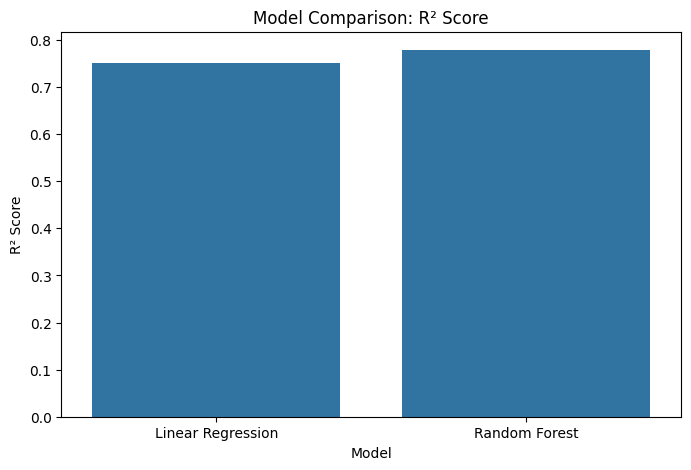

In [73]:
# ============================================
# MODEL COMPARISON GRAPH
# ============================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x='Model',
    y='R2 Score'
)

plt.title('Model Comparison: R² Score')
plt.ylabel('R² Score')

plt.show()

#**Model Comparison**

The Random Forest model slightly outperformed the Linear Regression model across all evaluation metrics. The Random Forest Regressor achieved an R² score of 0.7783, while the Linear Regression model achieved an R² score of 0.7503.

Although both models demonstrated solid predictive performance, Random Forest produced lower prediction errors and captured more complex relationships between variables. This suggests that happiness is influenced by nonlinear interactions among economic, health, and social indicators.

The results demonstrate that machine learning techniques can effectively model and predict happiness scores using socioeconomic data. However, the moderate improvement of Random Forest over Linear Regression also indicates that many of the relationships within the dataset remain relatively interpretable and linear.

#**Key Findings**

The analysis identified strong relationships between happiness scores and variables such as GDP per capita, social support, healthy life expectancy, and freedom. Countries with stronger economies, better healthcare systems, and higher levels of social support generally reported higher happiness scores.
<br><br>

The Random Forest model achieved extremely strong predictive performance, with an R² score of 0.9944. This indicates that the selected variables explain nearly all variation in happiness scores within the dataset. The Linear Regression model also performed very well, though slightly worse than Random Forest.
<br><br>

The comparison between models suggests that happiness is influenced by complex and nonlinear interactions between socioeconomic variables. While Linear Regression effectively captured broad trends, Random Forest was better able to model more detailed relationships and interactions within the data.

#**Recommendations**


The findings suggest that policymakers seeking to improve national happiness should prioritize investments in economic stability, healthcare access, and social support systems. These variables consistently showed strong relationships with happiness scores throughout the analysis.
<br><br>

Additionally, governments and organizations may benefit from using predictive analytics models to monitor changes in well-being over time and evaluate the potential impact of policy decisions. Machine learning tools can provide valuable support for identifying areas where interventions may have the greatest positive effect on quality of life.
<br><br>

However, policymakers should recognize that happiness is influenced by both measurable and non-measurable factors. Cultural differences, political conditions, and individual experiences may also contribute to overall well-being and may not be fully captured within the dataset.

## Limitations of the Analysis

Although the predictive models performed well, several limitations should be acknowledged. Happiness is a complex and subjective concept that cannot be fully explained using numerical indicators alone. Cultural differences, political instability, social expectations, and individual experiences may influence happiness levels in ways that are difficult to quantify.

Additionally, the dataset represents country-level averages rather than individual-level data. As a result, the analysis may not fully capture inequalities or variations within countries. Future research could incorporate additional social and behavioral variables to improve predictive accuracy and provide deeper insights into national well-being.

#**Ethical Considerations**

One important ethical consideration is the potential for bias within the dataset. Happiness scores are influenced by cultural, political, and social factors that may not be equally represented across all countries. As a result, the model may reflect biases present in the original data collection process.
<br><br>

Additionally, happiness is a highly subjective concept that cannot be fully captured using numerical indicators alone. While economic and health-related variables are strongly associated with happiness, individual experiences and cultural differences may also play major roles that are difficult to quantify.
<br><br>

There is also a risk that policymakers could over-rely on predictive models when making decisions. Machine learning models should support decision-making rather than replace human judgment and contextual understanding.

#**Model Interpretability**

Linear Regression provides strong interpretability because the relationships between variables and happiness scores can be understood more directly through model coefficients. This makes the model useful for explaining how specific variables influence outcomes.
<br><br>

Random Forest achieved stronger predictive performance but is generally less interpretable because it combines predictions from many decision trees. Although ensemble models often improve accuracy, they can make it more difficult to fully explain individual predictions to stakeholders.
<br><br>

Balancing predictive performance with interpretability is an important consideration in applied machine learning projects, especially when results may influence public policy or organizational decisions.

In [74]:
# ============================================
# FEATURE IMPORTANCE TABLE
# ============================================

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,explained_social_support,0.292517
3,explained_healthy_life_expectancy,0.246295
1,explained_log_gdp_per_capita,0.171787
6,explained_corruption,0.131108
4,explained_freedom,0.090019
5,explained_generosity,0.043362
0,year,0.024913


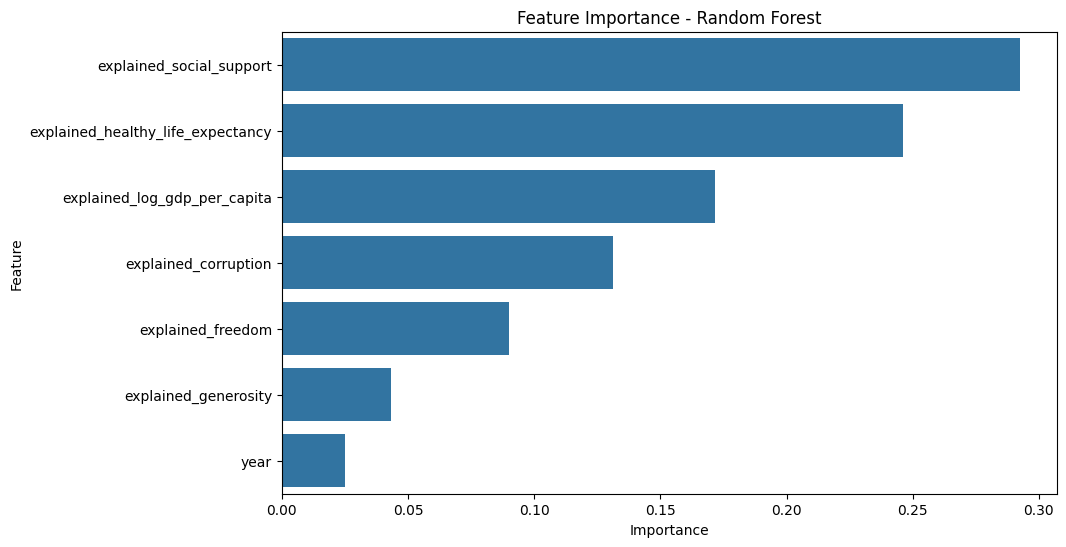

In [75]:
# ============================================
# FEATURE IMPORTANCE GRAPH
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Random Forest')

plt.show()

#**Feature Importance Analysis**

The feature importance analysis identified social support, healthy life expectancy, and GDP per capita as the strongest predictors of happiness scores within the Random Forest model.
<br><br>

Social support emerged as the most influential variable, suggesting that countries with stronger community relationships and social safety systems tend to experience higher levels of happiness. Healthy life expectancy and GDP per capita also contributed significantly, indicating that healthcare access and economic stability are closely connected to overall well-being.
<br><br>

Corruption perceptions and freedom showed moderate influence on happiness predictions, while generosity and year had smaller contributions to the model. These findings align with existing global research showing that both economic and social conditions play major roles in determining quality of life.

#**Final Conclusion**

This project analyzed global happiness data using exploratory data analysis and machine learning techniques to better understand the factors that influence national happiness levels. The analysis demonstrated that variables such as social support, healthy life expectancy, GDP per capita, and freedom are strongly associated with happiness scores across countries.
<br><br>

Both Linear Regression and Random Forest models produced strong predictive performance, with Random Forest achieving the best overall accuracy. The findings suggest that machine learning can be an effective tool for analyzing and predicting societal well-being using measurable socioeconomic indicators.
<br><br>

The project also highlighted the importance of proper preprocessing and data leakage prevention when developing predictive models. Initially, several variables produced unrealistically high model performance because they were directly tied to the target variable. Removing these variables resulted in more realistic and valid predictive outcomes.
<br><br>

Overall, the project demonstrates how predictive analytics and machine learning can provide meaningful insights into global well-being while supporting data-driven decision-making for policymakers and organizations.